## Despacho Ecónomico con Reserva, det, S, R, DR, DRCC
### Implementación en Clases Wrapper para facilitar Out of Sample Testing

In [24]:
spvc1=np.array([0]*6+[0.038, 0.188, 0.421,
       0.676, 0.883, 0.988, 0.962, 0.812, 0.579, 0.324, 0.117, 0.012]+[0]*6)
SPV_MPPT_1=Generator('SPV',rate_copkwh=80,power_perunit_kw=[250]*28,IBR=2,gen_curve_pu=spvc1) 
WT_MPPT_1=Generator('WT',110,[100]*20,IBR=2,gen_curve_pu=[0.3]*12+[0.8]*12)
Diesel1=Generator('Diesel',900,[1250,1000,910,510,510],UR=1500,DR=1500)
Biomass1=Generator('Biomass',500,[560]*3,UR=3*200,DR=3*200)
demc1=np.array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,0.786, 0.837,
       0.878, 0.878, 0.959, 1., 0.98 , 0.959, 0.918,0.939, 0.959, 0.98 , 0.994, 0.959, 0.898])
#Fortress Power eVault Max 18.5 kWh x Nmodulos
lifecycle_optimism=1.25
BESS1=BESS(nmods=450,ch_eff=0.83,dc_eff=0.8,lifecycle=8000*lifecycle_optimism,
           capcost_copkwh=1.2e6,modulecap_kwh=0.8*18.5,modulepower_kw=9.2)
MG1_nominal=MG(6000,demc1,True,Gens=(SPV_MPPT_1,WT_MPPT_1,Diesel1,Biomass1),BESS=BESS1)
print(MG1_nominal)


# im kinda assuming NOTC 800W/m2 instead of STC(1kW/m2)


spvc2=np.array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.038, 0.188, 0.421,
       0.676, 0.883, 0.988, 0.962, 0.812, 0.579, 0.324, 0.117, 0.012,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])
# im kinda assuming NOTC 800W/m2 instead of STC(1kW/m2)
SPV_MPPT_2=Generator('SPV',85,[100]*35,IBR=2,gen_curve_pu=spvc2*0.8) 
Gas2=Generator('Gas',720,[750,750,1250,1250])
PCH2=Generator('PCH',380,[1650]*4,UR=500*4,DR=500*4)
demc2=np.array([0.56, 0.53, 0.52, 0.53, 0.55, 0.63, 0.71, 0.73, 0.75, 0.78, 0.81,
       0.8, 0.8 , 0.83, 0.85, 0.85, 0.86, 0.95, 0.96, 1 ,0.96, 0.87,0.67,0.61])
lifecycle_optimism=1.25
# Pylontech US5000
BESS2=BESS(nmods=560)
MG2_nominal=MG(3800,demc2,Gens=(Gas2,PCH2,SPV_MPPT_2),has_bess=True,BESS=BESS2)
MG2_nominal

MG(peak_demand_kw=6000, demand_curve_pu=array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,
       0.786, 0.837, 0.878, 0.878, 0.959, 1.   , 0.98 , 0.959, 0.918,
       0.939, 0.959, 0.98 , 0.994, 0.959, 0.898]), demand_curve_kw=array([5142., 5082., 4776., 4518., 4470., 4284., 4038., 4284., 4590.,
       4716., 5022., 5268., 5268., 5754., 6000., 5880., 5754., 5508.,
       5634., 5754., 5880., 5964., 5754., 5388.]), has_bess=True, BESS=BESS(nmods=450, ch_eff=0.83, dc_eff=0.8, lifecycle=10000.0, cap_kwh=6660.0, power_kw=4140.0, power_kw_ch=4140.0, power_kw_dc=4140.0, syscost_cop=7992000000.0, throughput_kwh=66600000.0, dischargecostperkwh=120.0), Gens=(Generator(type='SPV', rate_copkwh=80, power_perunit_kw=[250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250], power_kw=7000, gen_curve_pu=array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.038, 0.188, 0.421,
       0.676, 0.883, 0.988,

MG(peak_demand_kw=3800, demand_curve_pu=array([0.56, 0.53, 0.52, 0.53, 0.55, 0.63, 0.71, 0.73, 0.75, 0.78, 0.81,
       0.8 , 0.8 , 0.83, 0.85, 0.85, 0.86, 0.95, 0.96, 1.  , 0.96, 0.87,
       0.67, 0.61]), demand_curve_kw=array([2128., 2014., 1976., 2014., 2090., 2394., 2698., 2774., 2850.,
       2964., 3078., 3040., 3040., 3154., 3230., 3230., 3268., 3610.,
       3648., 3800., 3648., 3306., 2546., 2318.]), has_bess=True, BESS=BESS(nmods=560, ch_eff=0.86, dc_eff=0.83, lifecycle=8000, cap_kwh=2553.6, power_kw=2688.0, power_kw_ch=2688.0, power_kw_dc=2688.0, syscost_cop=3319680000.0, throughput_kwh=20428800.0, dischargecostperkwh=162.5), Gens=(Generator(type='Gas', rate_copkwh=720, power_perunit_kw=[750, 750, 1250, 1250], power_kw=4000, gen_curve_pu=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1.]), intermittent=False, dispatchable=True, IBR=0, UR=40000, DR=40000, T=24), Generator(type='PCH', rate_copkwh=380, power_perunit_kw

[probEDNR.py:359 - CreateModel()] Model "Sep11_2230" created
[probEDNR.py:340 - __init__()] No training sample provided for Model. Update using updateTrainSampleSet(trainSampleSet) if needed.
[probEDNR.py:915 - solve_nominal()] Total Rsrv: +1.25MW, -2.40MW
[probEDNR.py:916 - solve_nominal()] Freq Limits: -1.5Hz, 2Hz, 
[probEDNR.py:917 - solve_nominal()] R_MG: 0.83Hz/MW, 8.333% puHz/puMW
[probEDNR.py:943 - solve_nominal()] Equal droops r: 20.35% puHz/puMW
[probEDNR.py:968 - solve_nominal()] For ['SPV', 'WT', 'Diesel', 'Biomass', 'BESS']
[probEDNR.py:969 - solve_nominal()] fpart: [0.01%, 0.00%, 28.53%, 11.47%, 60.00%]
[probEDNR.py:970 - solve_nominal()] R: [100000.00%, 100000.00%, 20.35%, 20.35%, 9.58%]% puHz/puMW
[probEDNR.py:971 - solve_nominal()] R: [8571.43, 30000.00, 2.92, 7.27, 1.39] Hz/MW
[probEDNR.py:972 - solve_nominal()] H+: [  0.   0. 357. 143. 750.]kW
[probEDNR.py:973 - solve_nominal()] H-: [   0.    0.  685.  275. 1440.]kW
[probEDNR.py:978 - solve_nominal()] params: {}
[prob

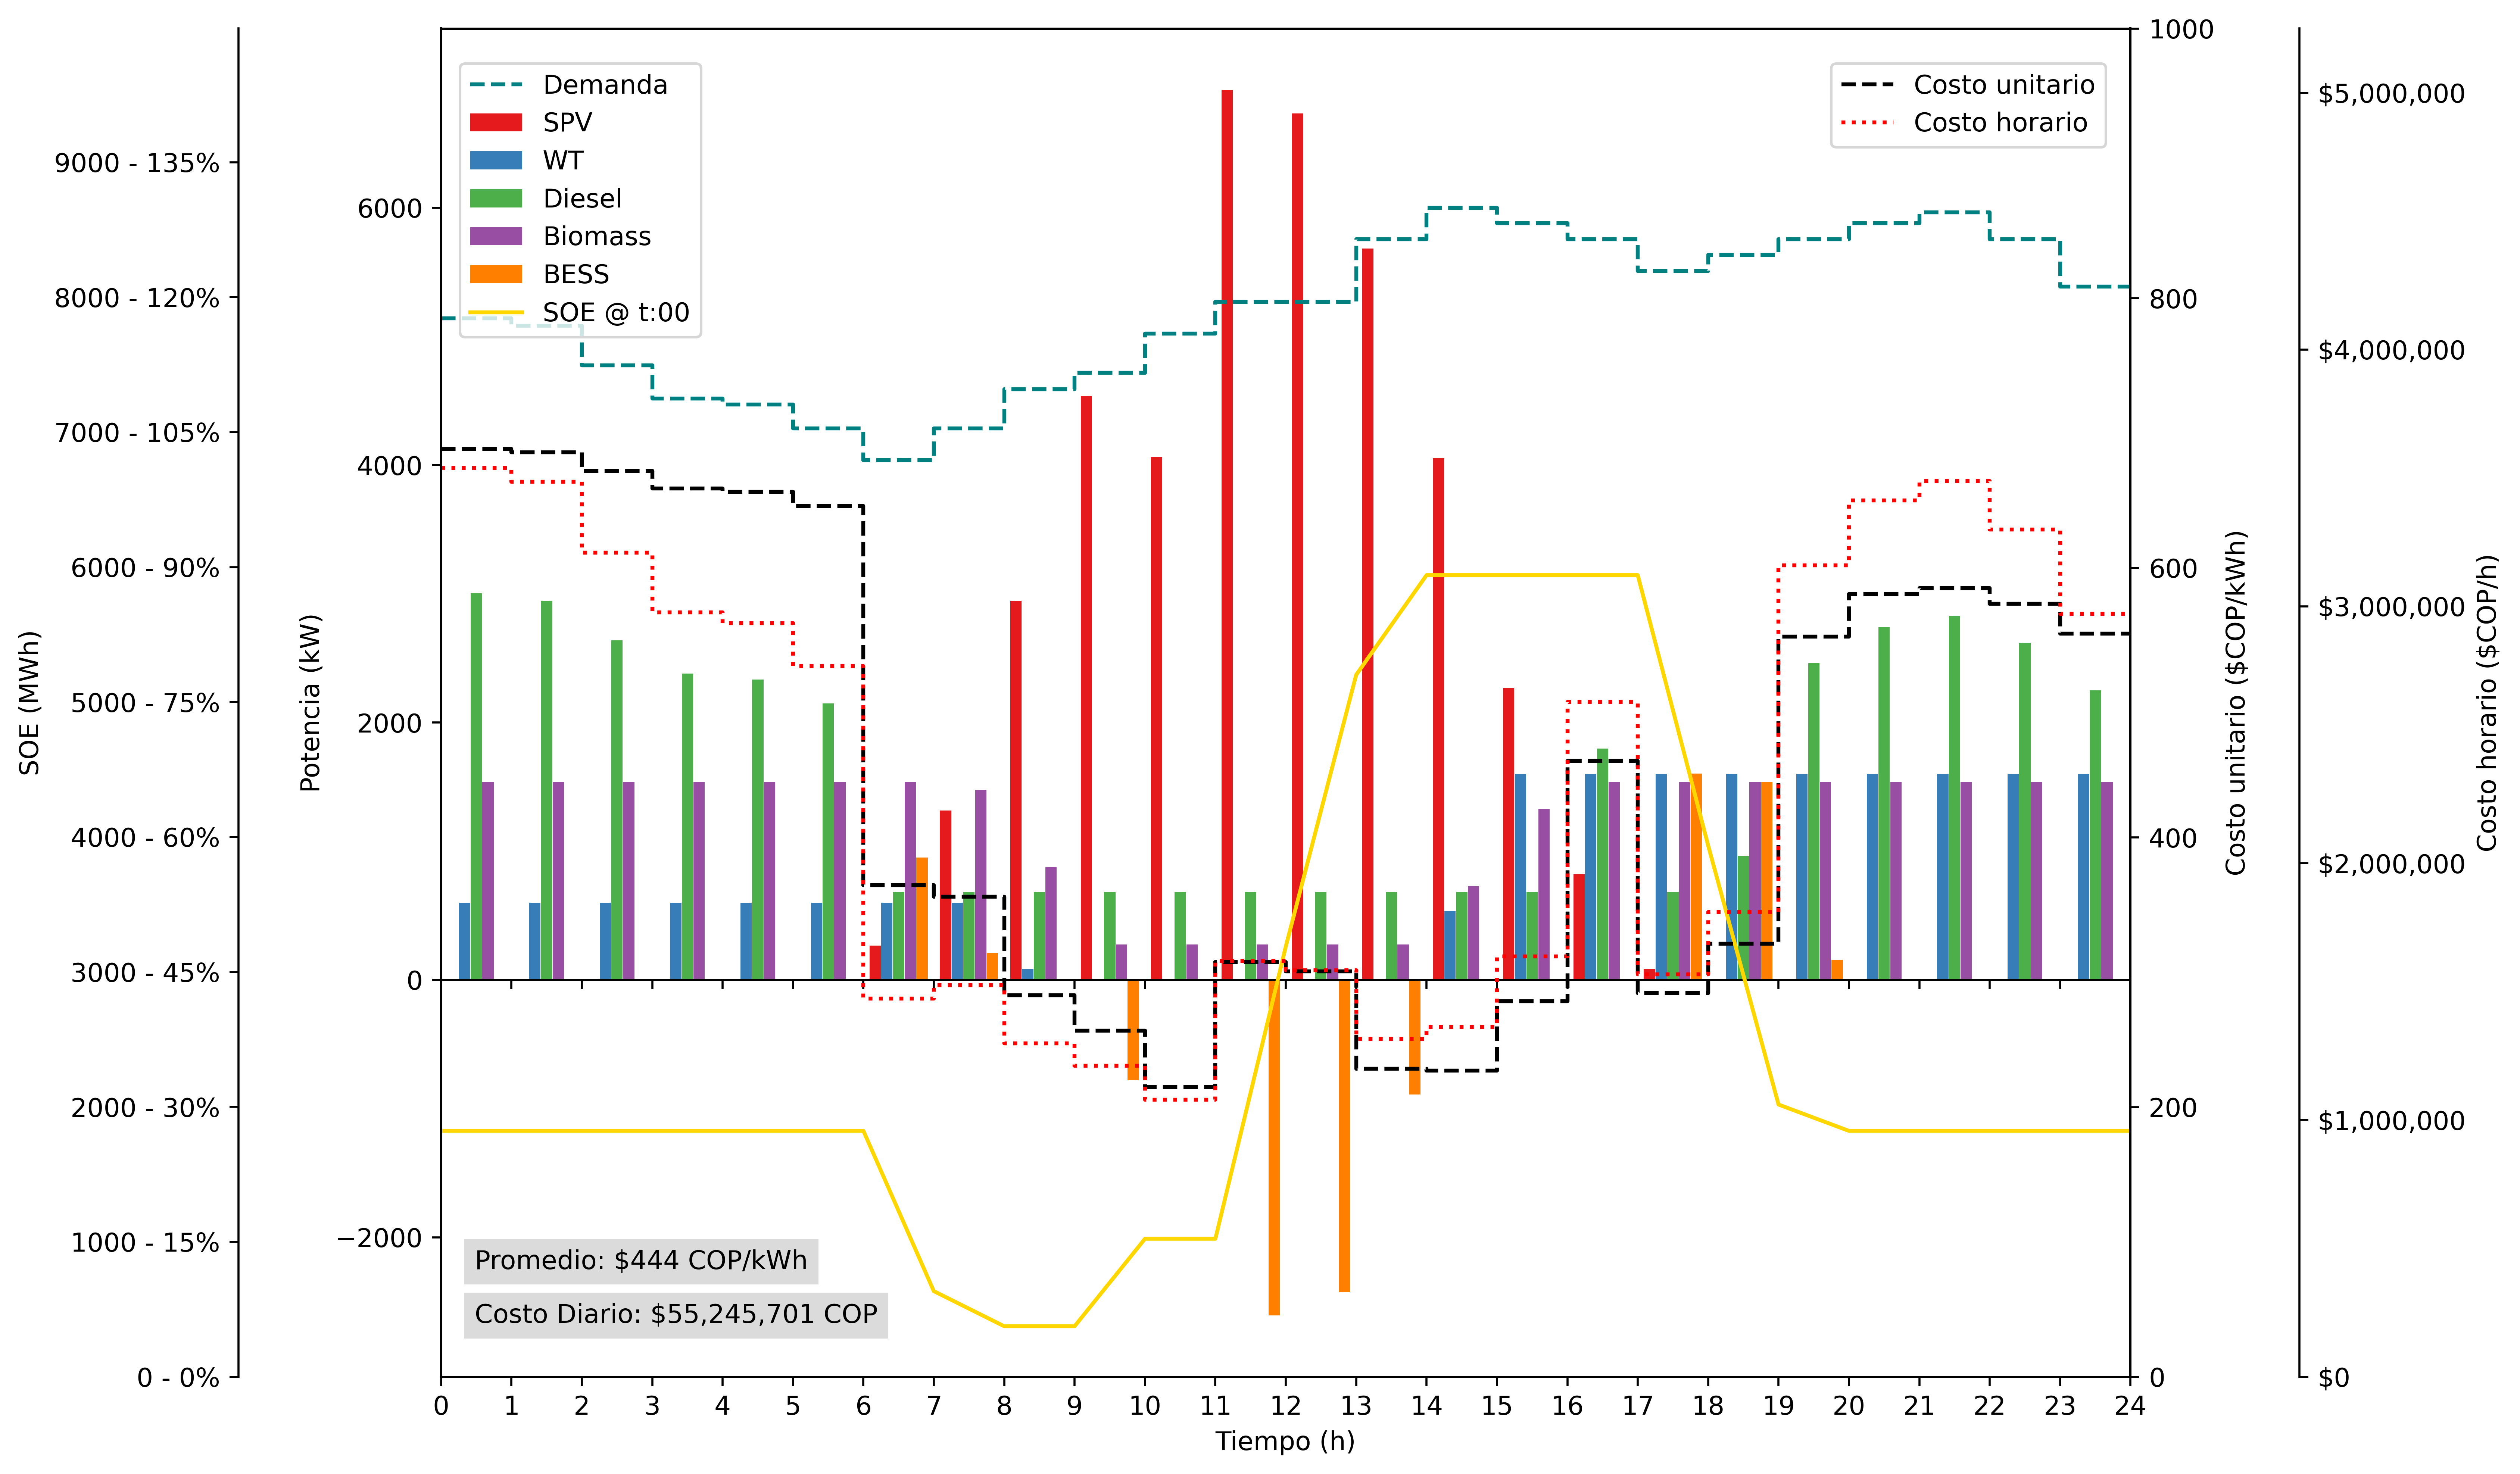

Res1: namespace(Pgen=array([[   0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,  266.        , 1316.        ,
        2947.        , 4536.81927711, 4062.        , 6916.        ,
        6734.        , 5684.        , 4053.        , 2268.        ,
         819.        ,   84.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ],
       [ 600.        ,  600.        ,  600.        ,  600.        ,
         600.        ,  600.        ,  600.        ,  600.        ,
          83.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,  535.        , 1600.        ,
        1600.        , 1600.        , 1600.        , 1600.        ,
        1600.        , 1600.        , 1600.        , 1600.        ],
       [3005.        , 2945.        , 2639.        , 2381.        ,
        2333.        , 2147.        ,  685.        ,  685.        ,
         685.        ,  6

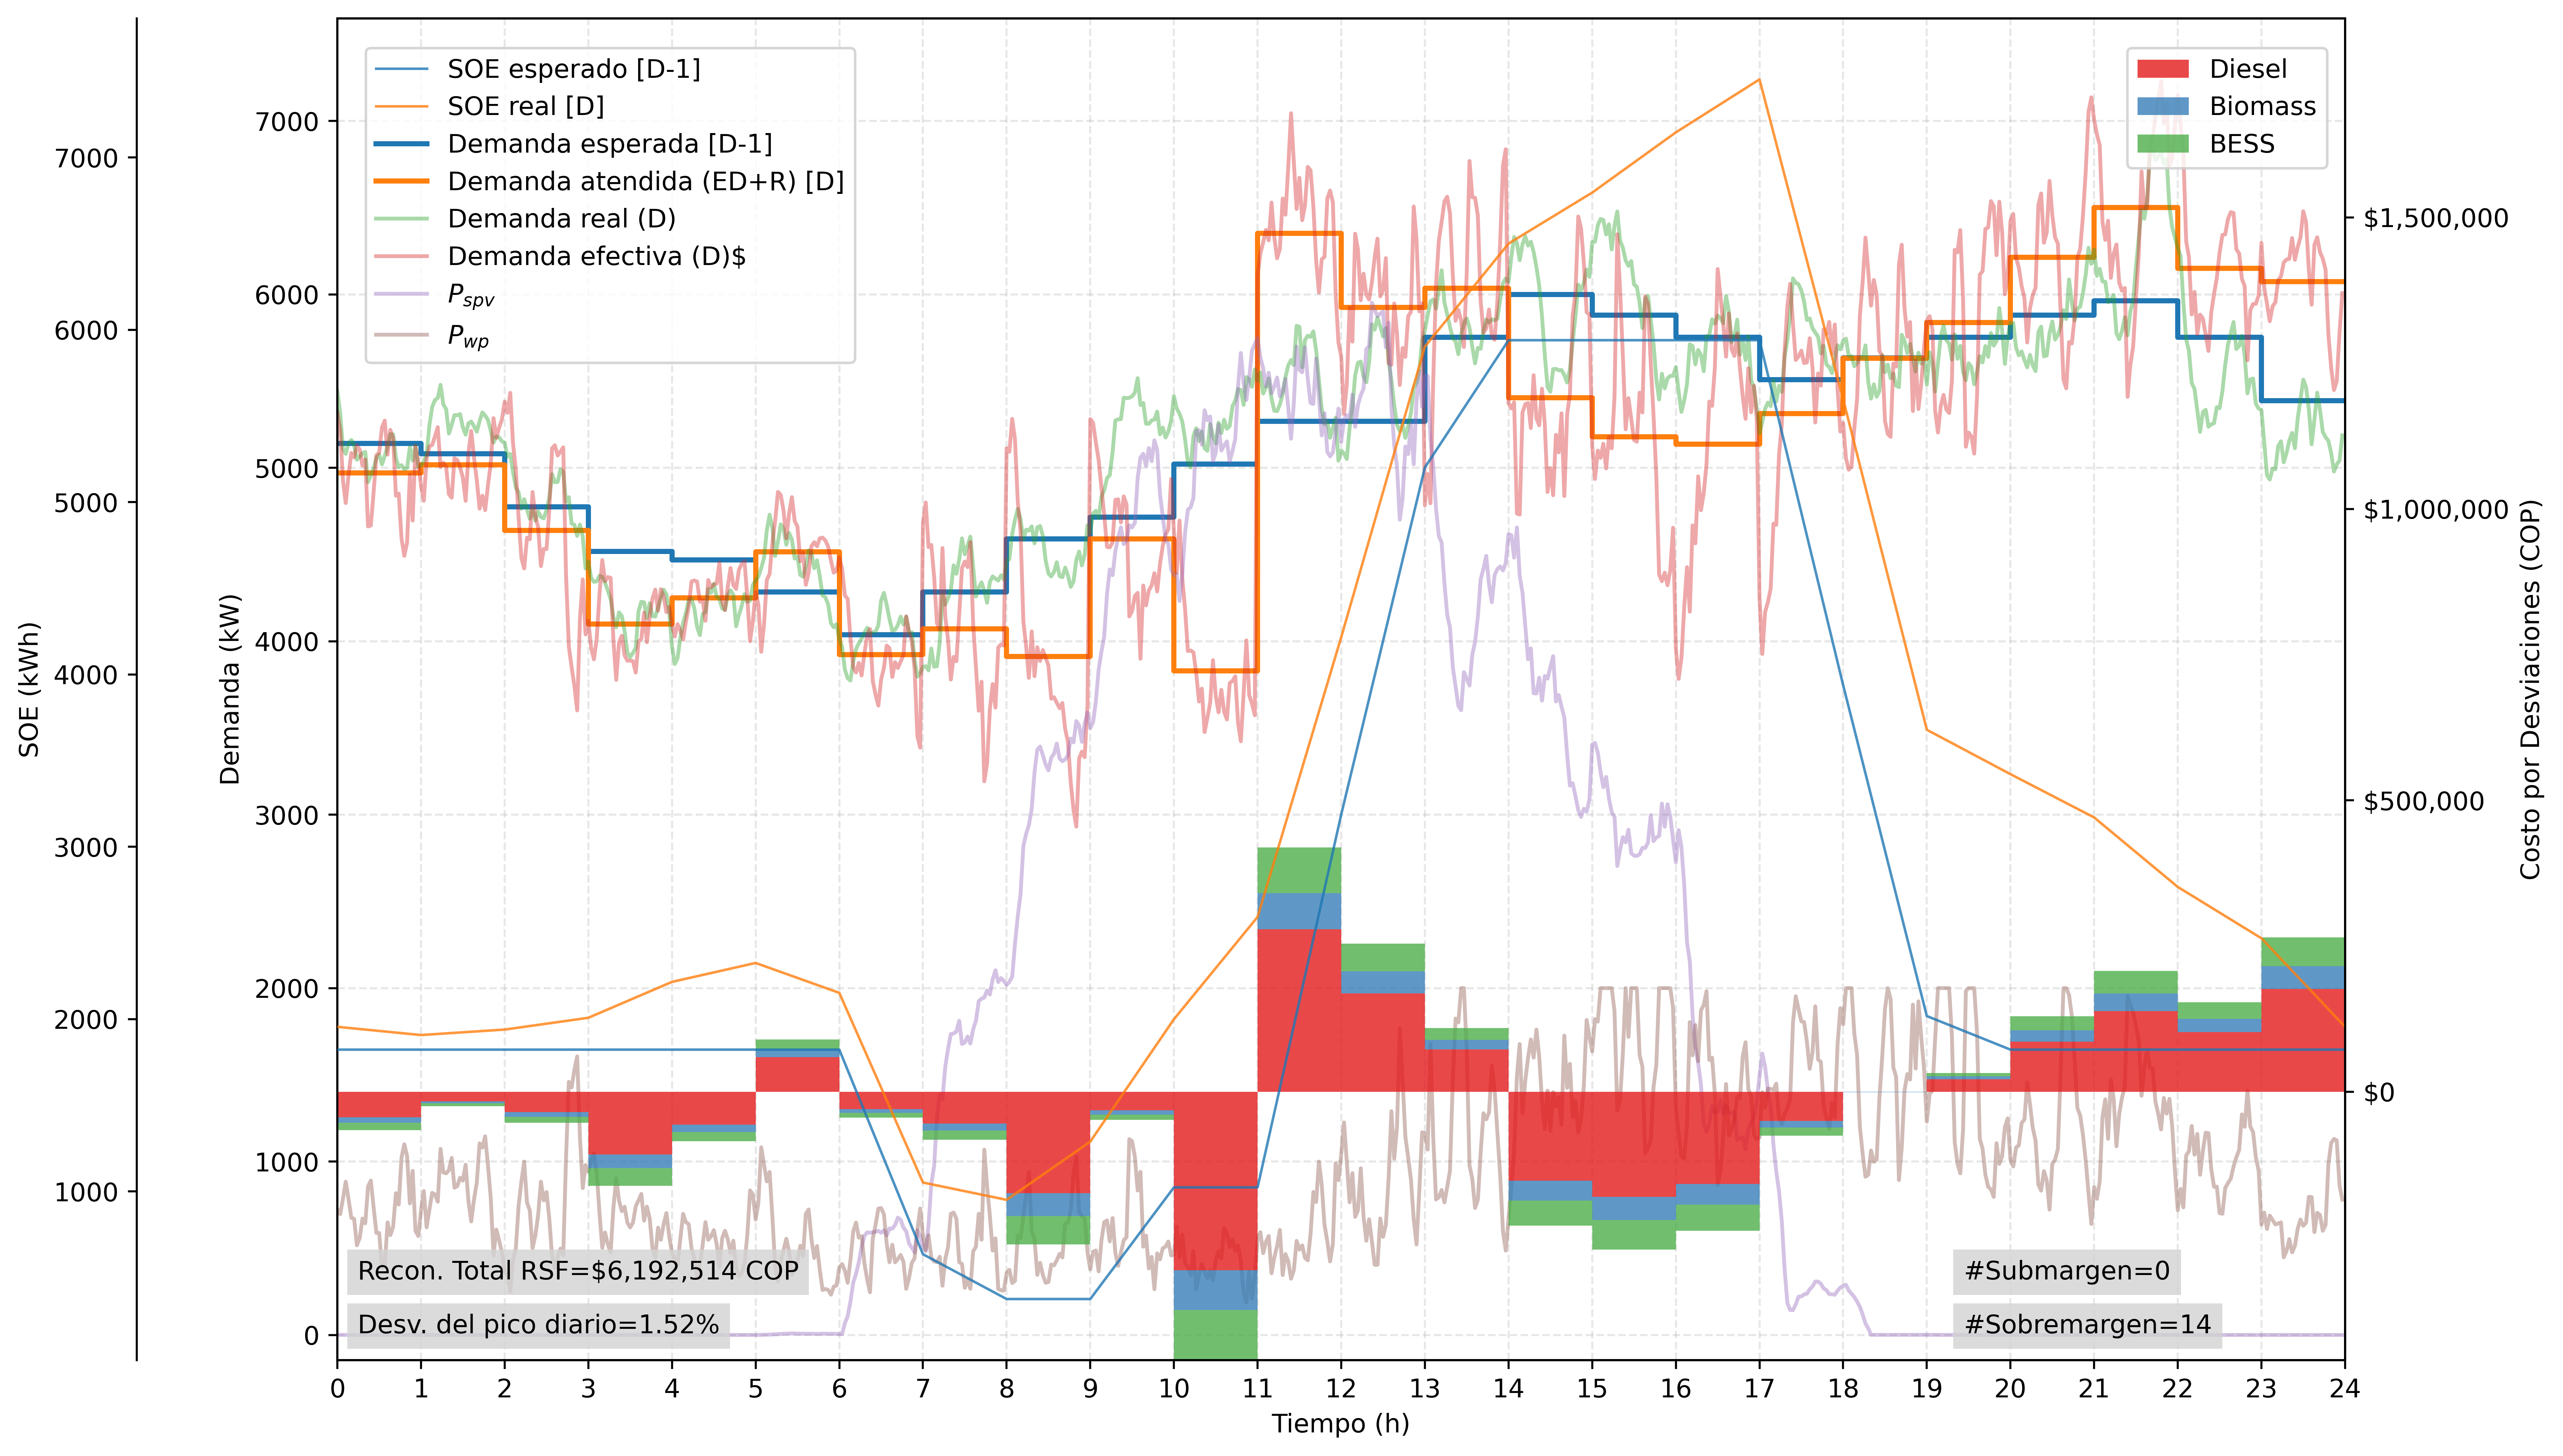

Res1_Test: namespace(RecCost=6192513.853735931, Nover=14, Nunder=0)


[probEDNR.py:157 - Joos()] Joos_: (59493476.2530329, 68832753.07473254, 68068968.52518587, 60727126.82587691, 64075377.54497283, 60520912.22763119, 66137293.90456957, 64172033.94148634, 63011869.61054616, 62246742.13352975)
[probEDNR.py:158 - Joos()] PrViol_: (0.027777777777777776, 0.09722222222222222, 0.06527777777777778, 0.013888888888888888, 0.043055555555555555, 0.059722222222222225, 0.03333333333333333, 0.08888888888888889, 0.041666666666666664, 0.044444444444444446)


Costo Reconcil. Promedio: $8,201,034 COP
Joos: $63,728,655 COP = ED+R + 8,201,034
PrViol: 5.15%


In [ ]:
# # # Logs completos
# Crear instacia y resolver caso nominal
MG1_det=detEDnR(MG1_nominal)
Res1=MG1_det.solve_nominal(Res_verbose=1,plot_ED=True,grb_verbose=False,EDplotstyle='bar')
print(f"Res1: {Res1}")

EDRcost=Res1.EDcost+Res1.Rcost
print(f"Costo ED+R: ${EDRcost:,.0f} COP")


# Config. seed de RNG, crear 1 muestra y probar desempeño en operación usando Res1 
MG1_det.rng=np.random.default_rng(42)
testDay1=MG1_det.generateDaySample()
# Es obligatorio configurar un generador de última instancia
MG1_det.LastInstance='BESS'
Res1_Test=MG1_det.MGOperation(Res1,testDay1,plot_op=True,plotDeltaSOE=True)
# print(f"Res1_Test: {Res1_Test}")

# # Ahora crear conjunto de muestras para probar el desempeño promedio
testSampleSet=MG1_det.generateSampleSet(10)
Joos,PrViol=MG1_det.Joos(Res1,testSampleSet)
AvgRecCost=Joos-EDRcost
print(f"Costo Reconcil. Promedio: ${AvgRecCost:,.0f} COP")
print(f"Joos: ${Joos:,.0f} COP = ED+R + {AvgRecCost:,.0f}")
print(f"PrViol: {PrViol:.2%}")


[2089794545.py:327 - CreateModel()] Model "Jul21_1757" created
[2089794545.py:308 - __init__()] No training sample provided for Model. Update using updateTrainSampleSet(trainSampleSet) if needed.
[2089794545.py:728 - solve()] previous nominal Day: {'peak_demand_kw': 6000, 'demand_curve_kw': array([5142., 5082., 4776., 4518., 4470., 4284., 4038., 4284., 4590.,
       4716., 5022., 5268., 5268., 5754., 6000., 5880., 5754., 5508.,
       5634., 5754., 5880., 5964., 5754., 5388.]), 'demand_curve_pu': array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,
       0.786, 0.837, 0.878, 0.878, 0.959, 1.   , 0.98 , 0.959, 0.918,
       0.939, 0.959, 0.98 , 0.994, 0.959, 0.898]), 'Psolar_kw': array([   0. ,    0. ,    0. ,    0. ,    0. ,    0. ,  212.8, 1052.8,
       2357.6, 3785.6, 4944.8, 5532.8, 5387.2, 4547.2, 3242.4, 1814.4,
        655.2,   67.2,    0. ,    0. ,    0. ,    0. ,    0. ,    0. ]), 'Pwind_kw': [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.8, 0

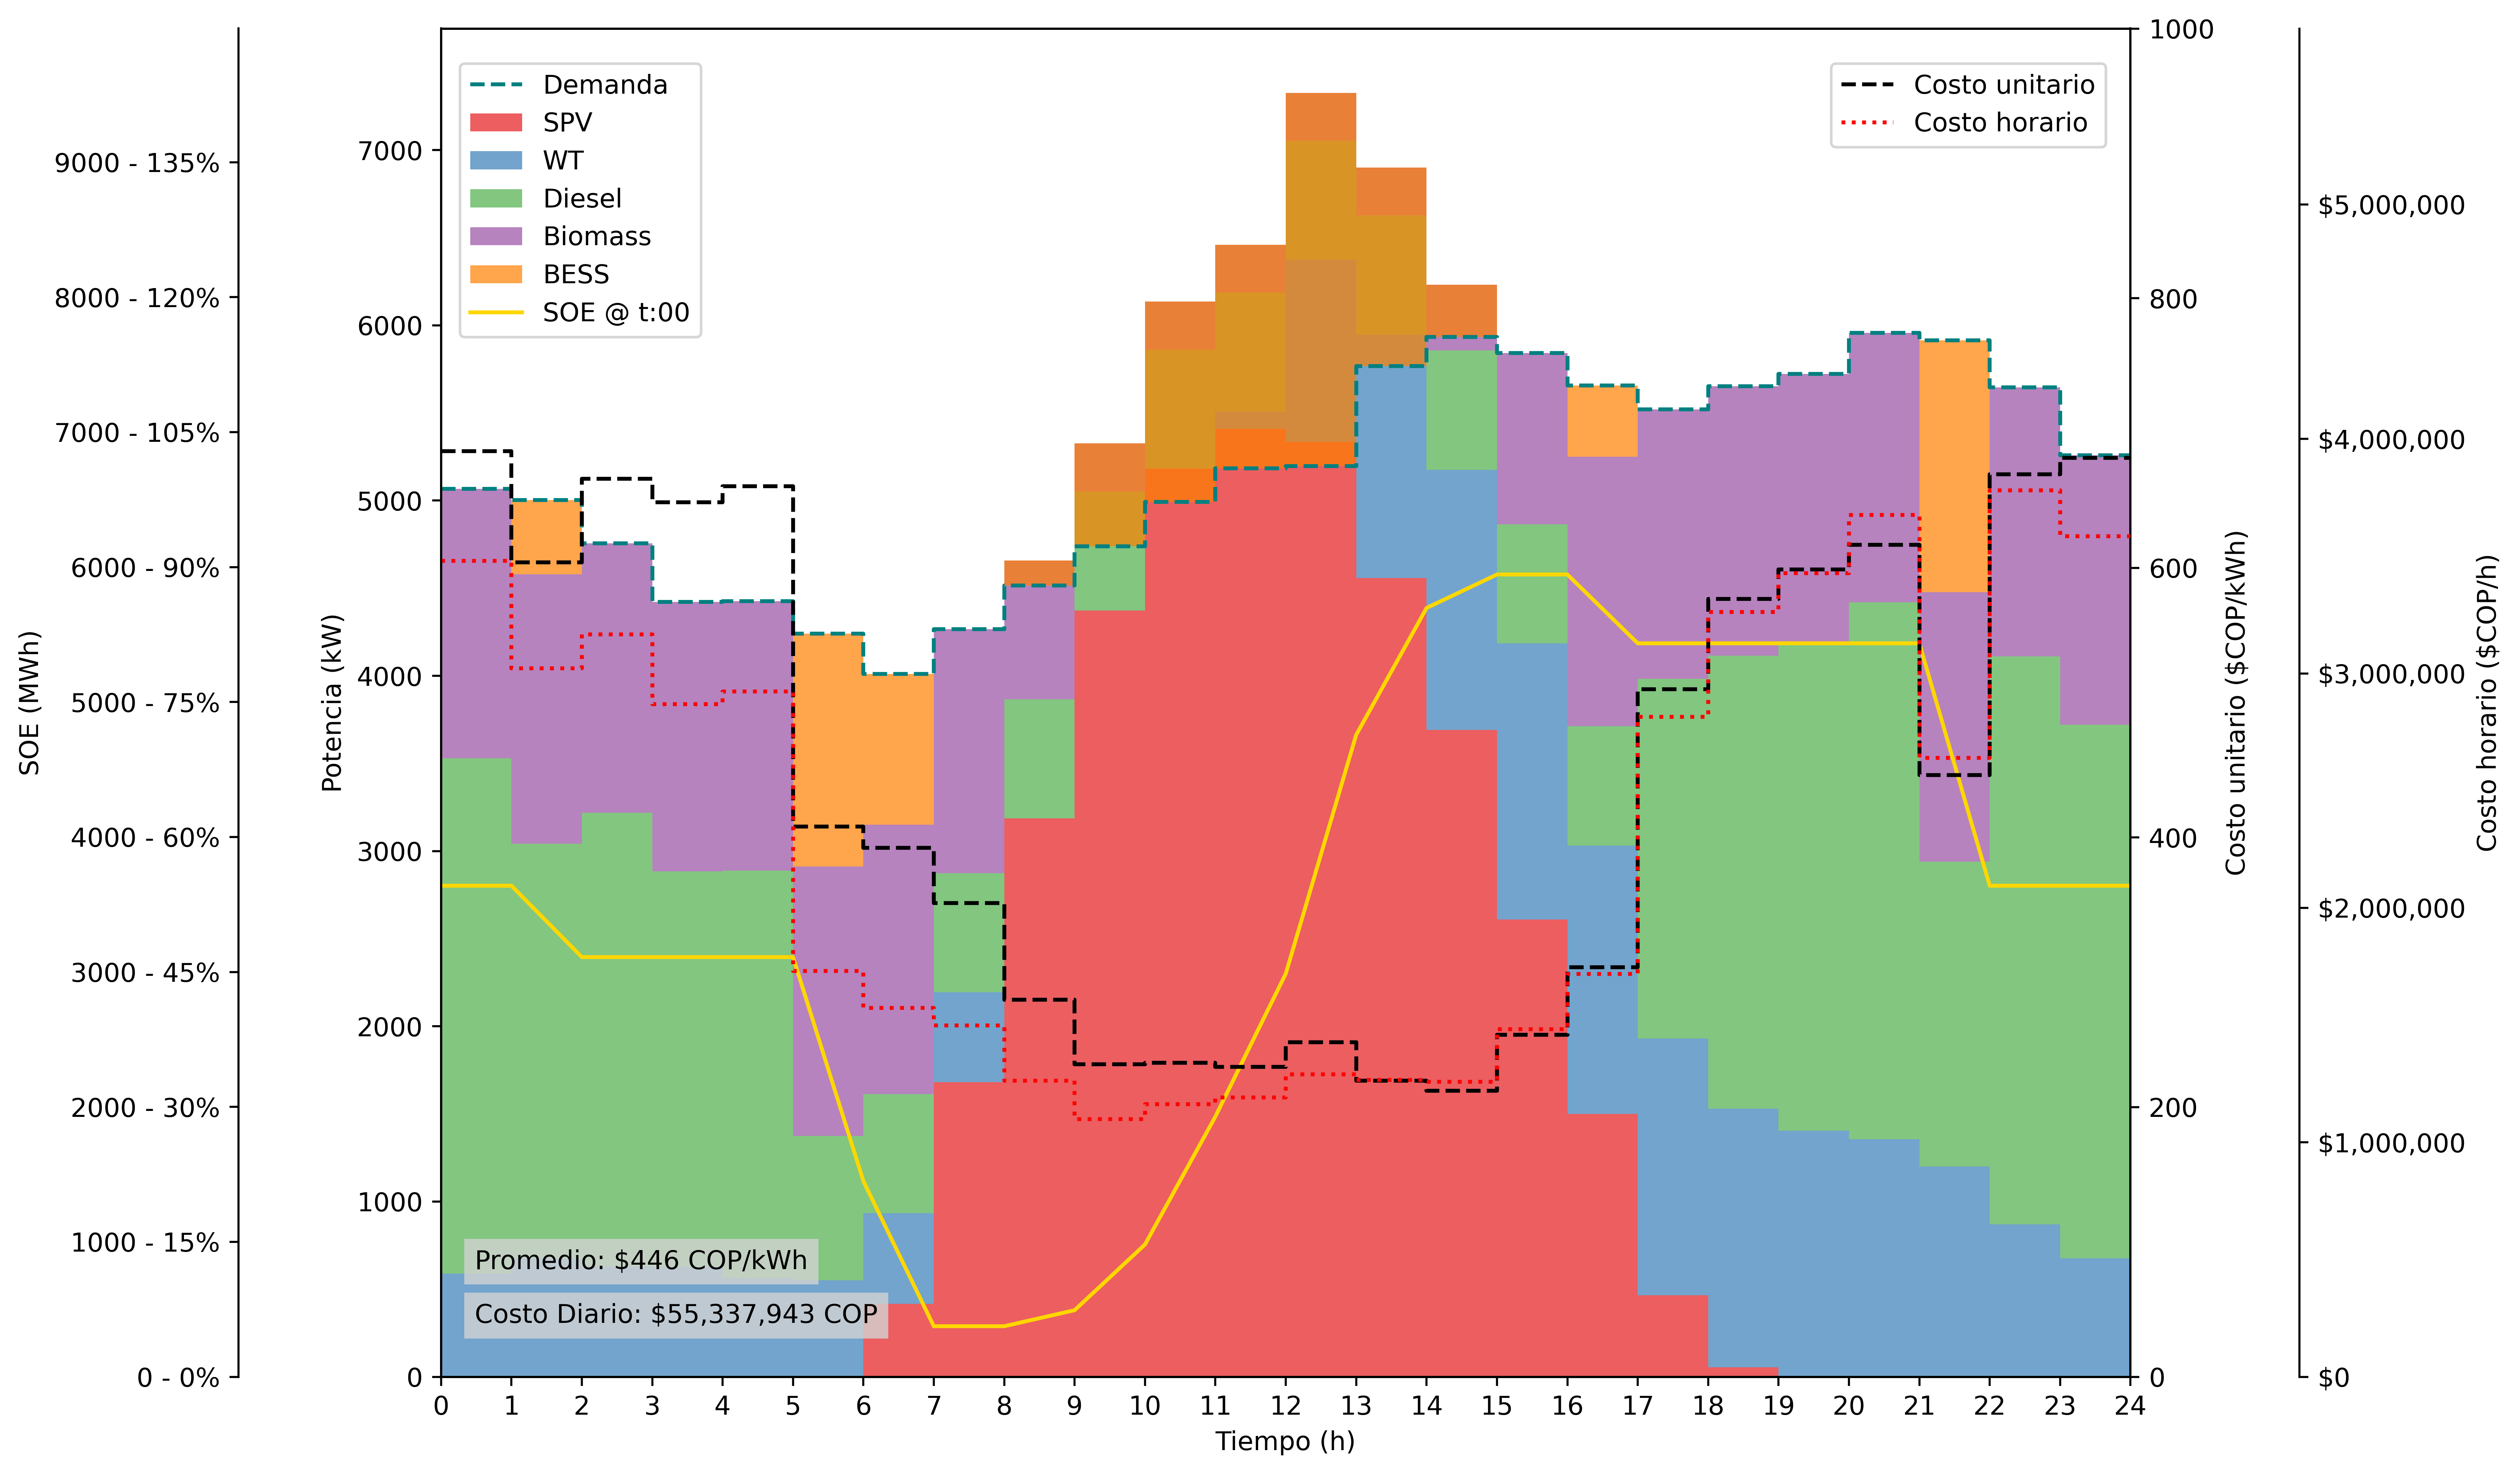

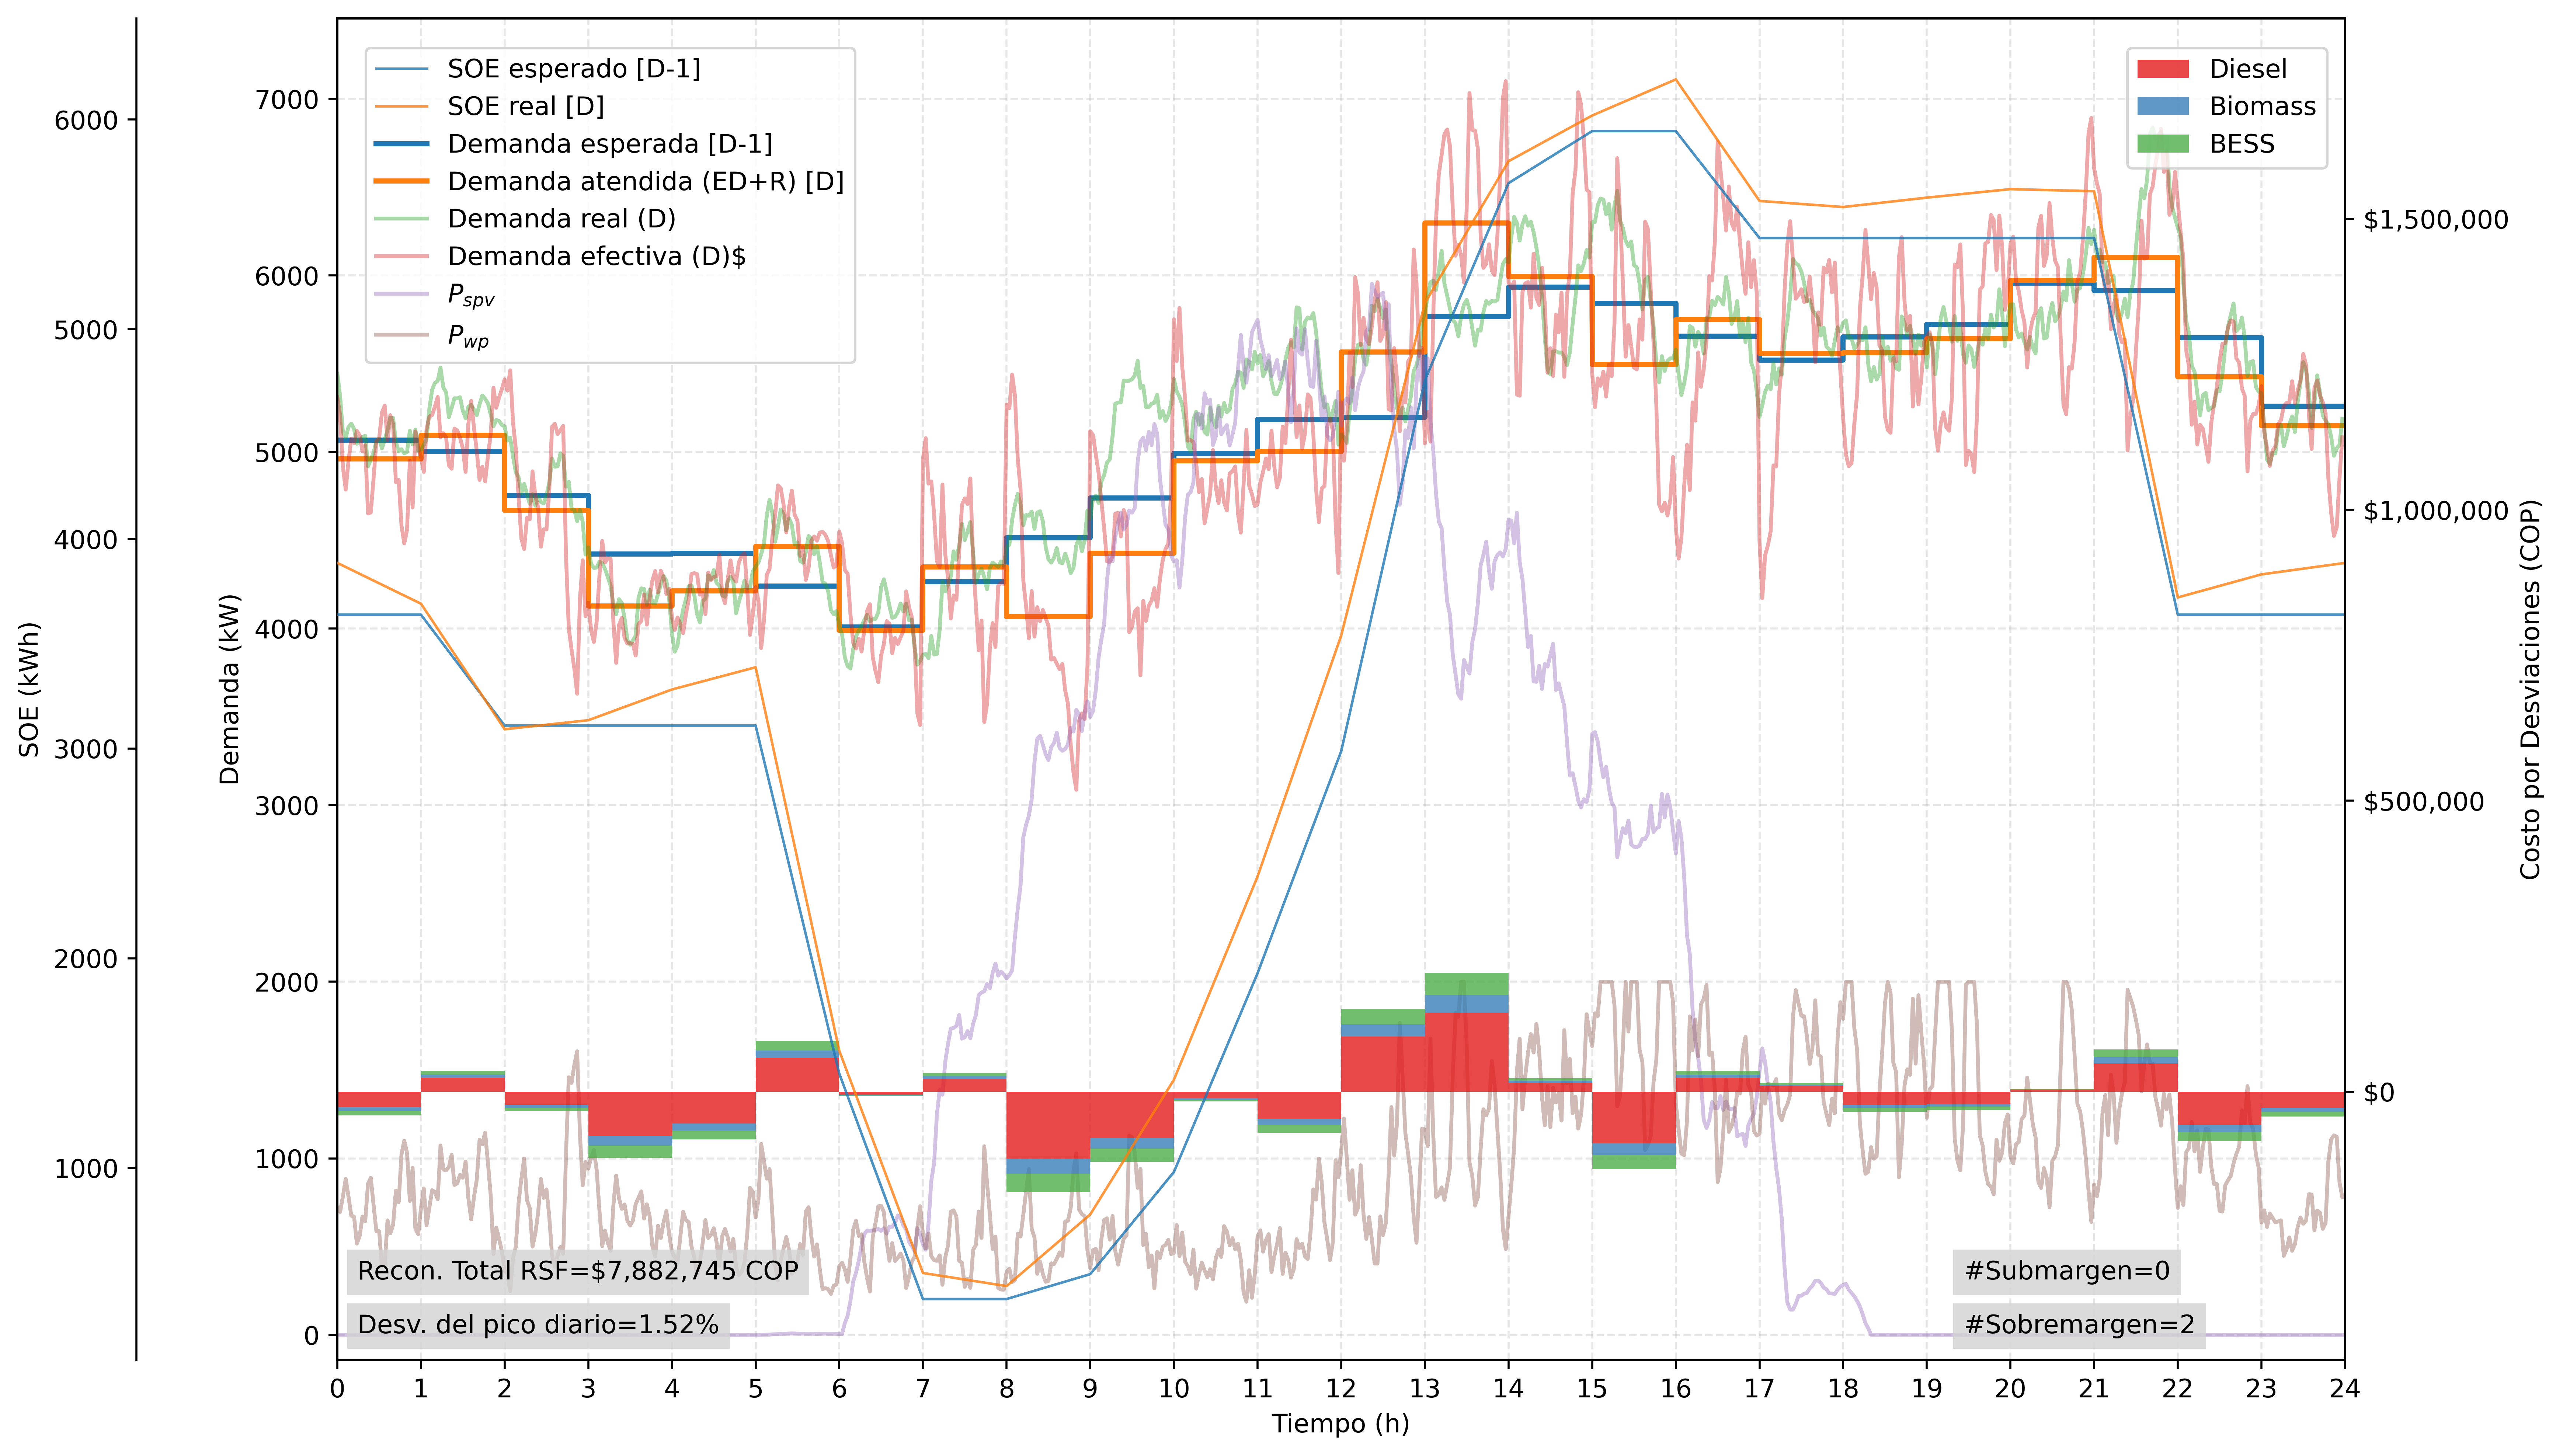

[2089794545.py:157 - Joos()] Joos_: (61095215.61994815, 70685872.80371231, 69699592.9215093, 62298205.116109915, 65705370.80135576, 62221579.153454244, 67721591.78695597, 65957181.70514892, 64674523.79438124, 63768230.35085718)
[2089794545.py:158 - Joos()] PrViol_: (0.0125, 0.0375, 0.030555555555555555, 0.009722222222222222, 0.020833333333333332, 0.029166666666666667, 0.008333333333333333, 0.03888888888888889, 0.0, 0.02638888888888889)


Costo Reconcil. Promedio: $9,948,233 COP
Joos: $65,382,736 COP = ED+R + 9,948,233
PrViol: 2.14%


In [ ]:
# Es posible que mejore el resultado usando una muestra de entrenamiento para calcular la operación nominal
MG1_det=detEDnR(MG1_nominal)
MG1_det.LastInstance='BESS'
trainSample=MG1_det.generateSampleSet(30) # Ejemplo: Se cuenta con 1 mes de mediciones
Res1_trained,Jis=MG1_det.solve(trainSample,Res_verbose=2,plot_ED=True,grb_verbose=False)

#Se evalúa el desempeño en un día
Res1_trained_test=MG1_det.MGOperation(Res1_trained,testDay1,plot_op=True,plotDeltaSOE=True)

# Y nuevamente en el conjunto de muestras de prueba
Joos,PrViol=MG1_det.Joos(Res1_trained,testSampleSet)
AvgRecCost=Joos-Jis
print(f"Costo Reconcil. Promedio: ${AvgRecCost:,.0f} COP")
print(f"Joos: ${Joos:,.0f} COP = ED+R + {AvgRecCost:,.0f}")
print(f"PrViol: {PrViol:.2%}")

[probEDNR.py:355 - __init__()] Instance set for non-transactive EDnR
[probEDNR.py:380 - CreateModel()] Model "Sep14_021340" created
[probEDNR.py:363 - __init__()] No training sample provided for Model. Update using updateTrainSampleSet(trainSampleSet) if needed.
[probEDNR.py:777 - updateNominalwithExpectFromSampleSet()] previous nominal Day: {'peak_demand_kw': 3800, 'demand_curve_kw': array([2128., 2014., 1976., 2014., 2090., 2394., 2698., 2774., 2850.,
       2964., 3078., 3040., 3040., 3154., 3230., 3230., 3268., 3610.,
       3648., 3800., 3648., 3306., 2546., 2318.]), 'demand_curve_pu': array([0.56, 0.53, 0.52, 0.53, 0.55, 0.63, 0.71, 0.73, 0.75, 0.78, 0.81,
       0.8 , 0.8 , 0.83, 0.85, 0.85, 0.86, 0.95, 0.96, 1.  , 0.96, 0.87,
       0.67, 0.61]), 'Psolar_kw': array([   0. ,    0. ,    0. ,    0. ,    0. ,    0. ,  106.4,  526.4,
       1178.8, 1892.8, 2472.4, 2766.4, 2693.6, 2273.6, 1621.2,  907.2,
        327.6,   33.6,    0. ,    0. ,    0. ,    0. ,    0. ,    0. ])}
[probED

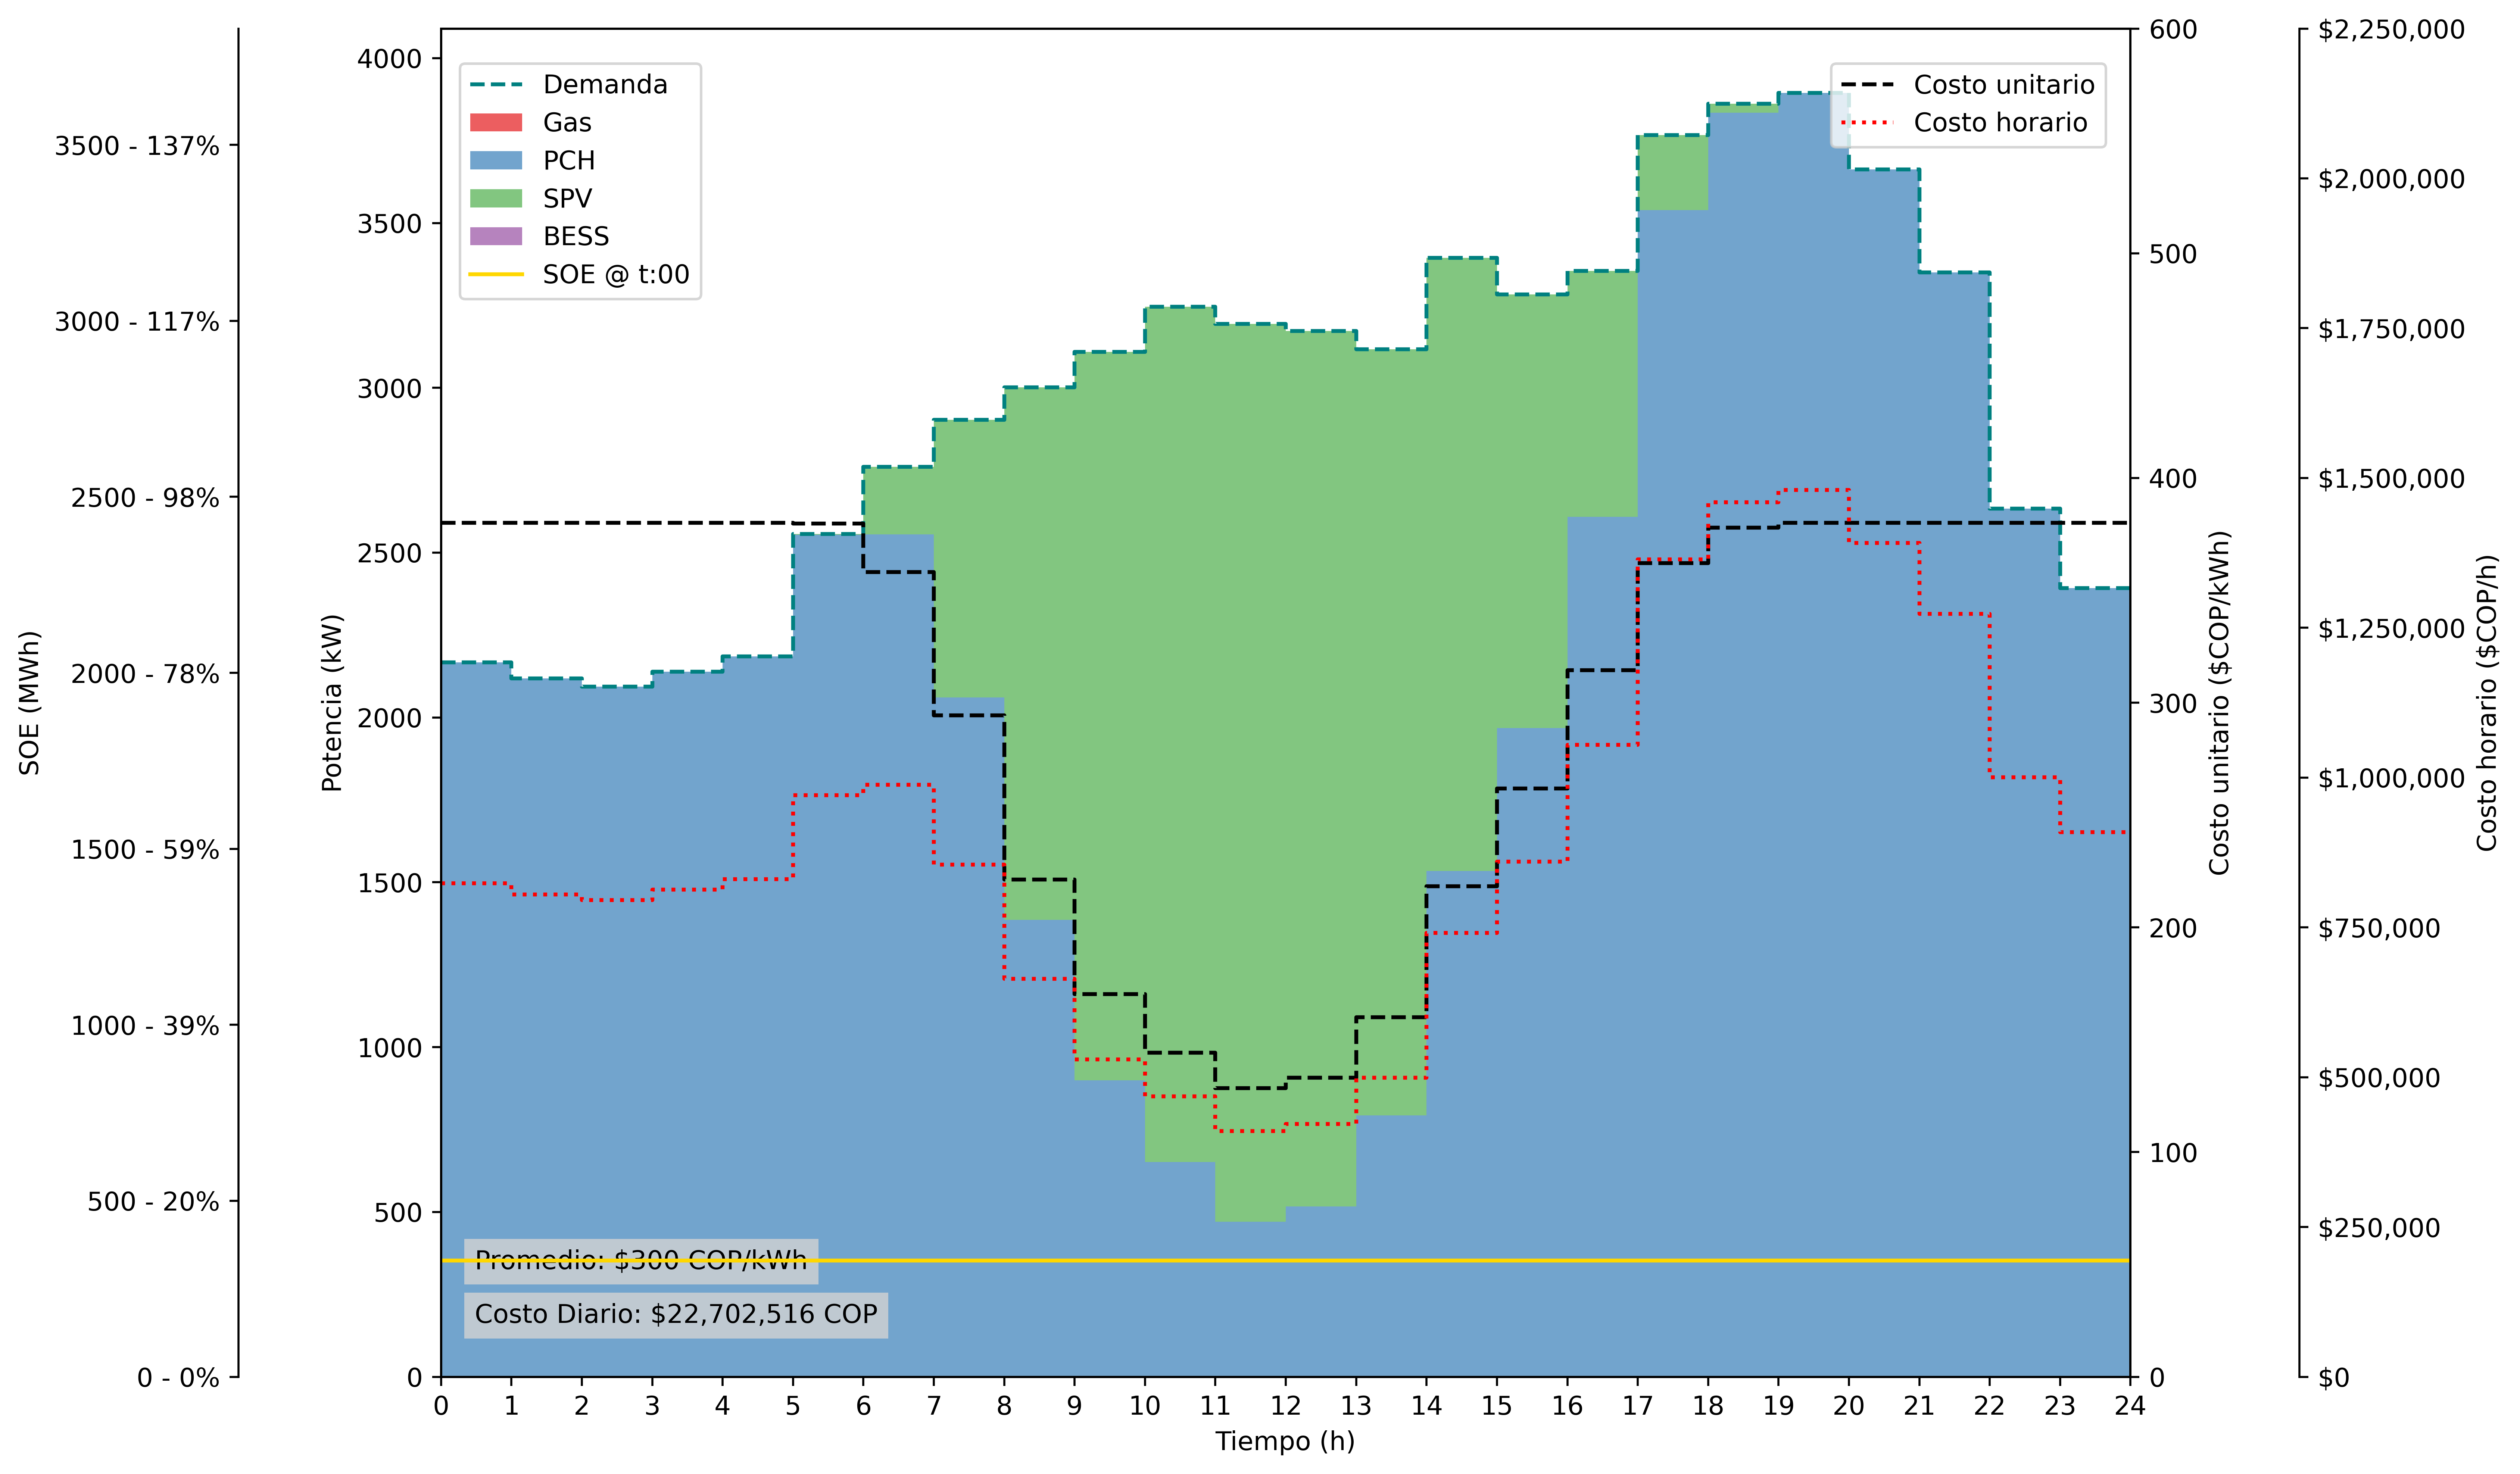

[probEDNR.py:155 - Joos()] Joos_: (22035125.02726686, 20325250.69216251, 21587689.88833344, 21780032.594315715, 22042571.20063905, 22282903.793492544, 20609158.184497844, 20417450.263414133, 22222237.823930673, 20003762.950943626, 20944320.149010073, 21752256.0789724, 22197338.425307058, 21380033.570968125, 23453675.242490765, 22269642.065342955, 21929314.974068724, 22791583.654354524, 20938017.180586528, 20692277.06806019, 21458478.592752326, 20710253.812817723, 22288597.96521567, 20288654.49785296, 22163747.212408222, 20617276.420554526, 22419794.447540663, 21548063.82175103, 22306798.31550995, 21607641.180865195, 21758831.061567403, 19725333.89956005, 21182993.160242908, 20882618.116330616, 22064439.53540417, 20284201.08429071, 22343661.446237177, 21161534.370474335, 22491182.372395445, 20425074.943957217, 22878313.016880482, 19745467.504344344, 20221782.13294947, 20641111.50231005, 18362455.896165013, 22265176.409495793, 21644653.403007023, 20738165.675371014, 21752368.160307188, 2

MG2_res: namespace(Pgen=array([[0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [2.167e+03, 2.118e+03, 2.094e+03, 2.139e+03, 2.185e+03, 2.554e+03,
        2.555e+03, 2.061e+03, 1.386e+03, 9.000e+02, 6.520e+02, 4.710e+02,
        5.170e+02, 7.930e+02, 1.534e+03, 1.968e+03, 2.609e+03, 3.539e+03,
        3.834e+03, 3.895e+03, 3.662e+03, 3.350e+03, 2.633e+03, 2.392e+03],
       [0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e+00,
        2.050e+02, 8.420e+02, 1.615e+03, 2.209e+03, 2.594e+03, 2.723e+03,
        2.655e+03, 2.324e+03, 1.860e+03, 1.315e+03, 7.460e+02, 2.280e+02,
        2.800e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]]), EDnRcost=22702516.225052357, fpart=array([[0.        , 0.        , 0.        , 0.  

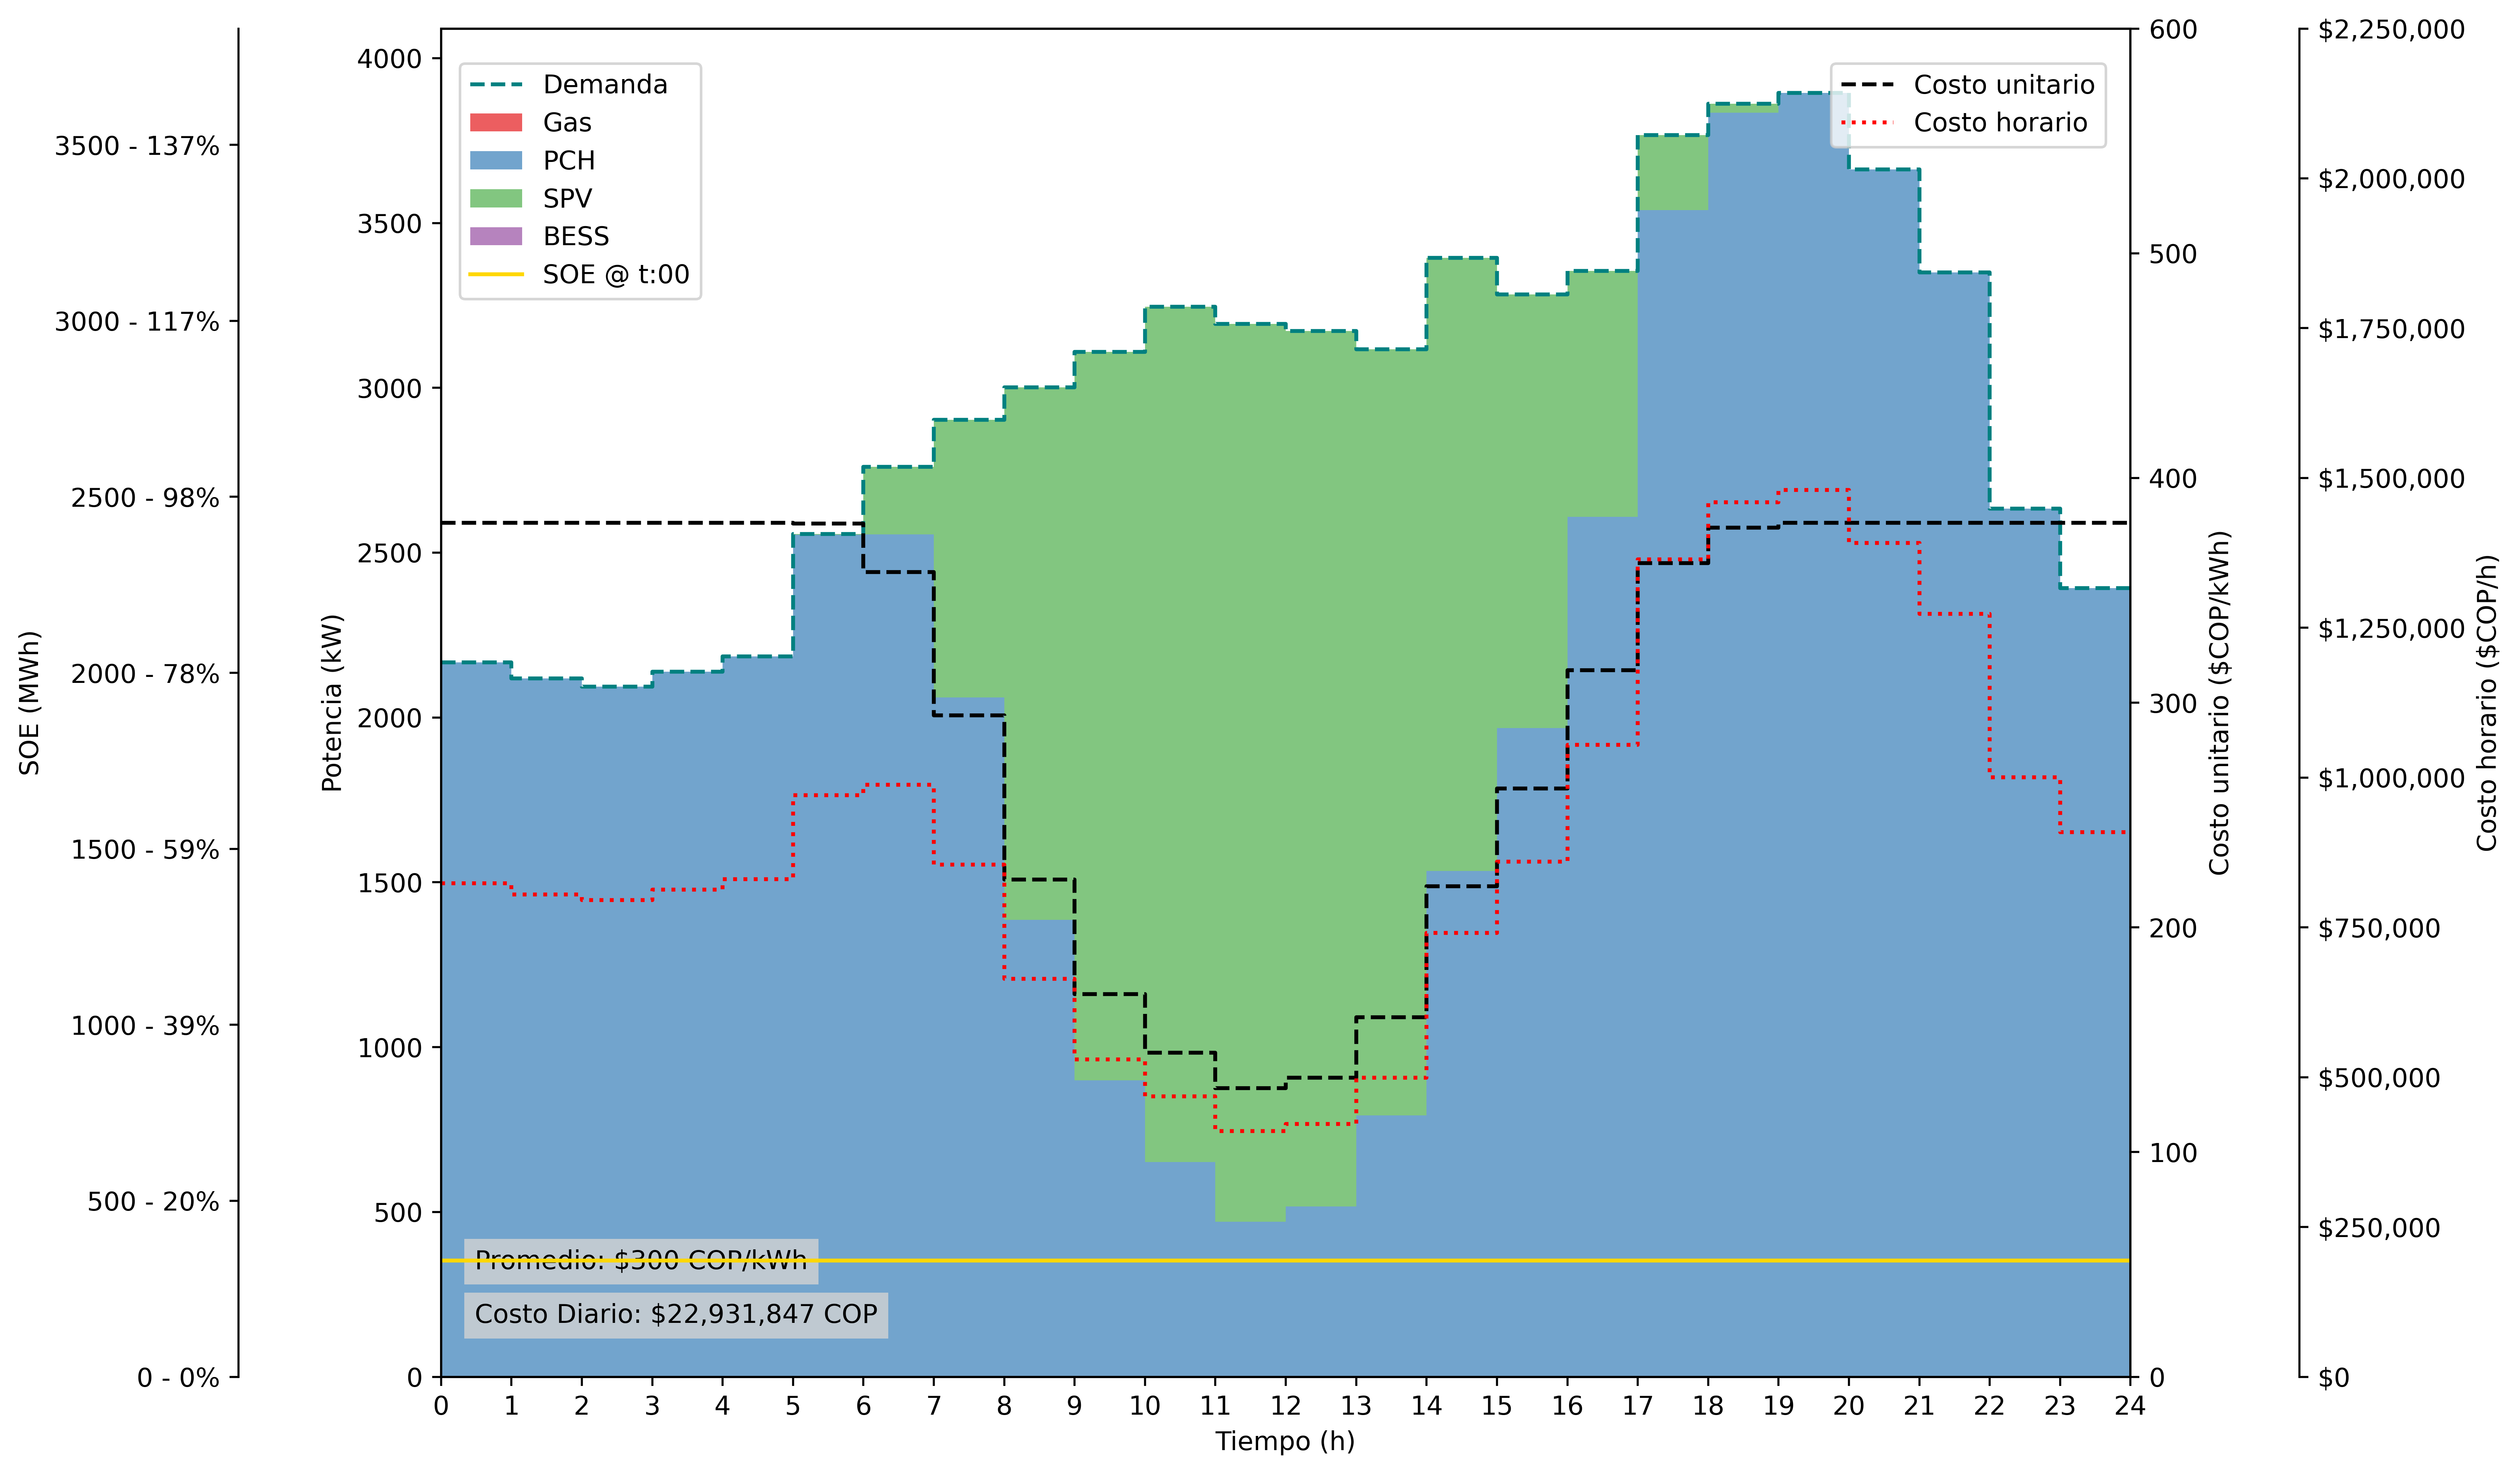

[probEDNR.py:155 - Joos()] Joos_: (22264455.804664418, 20554581.469560068, 21817020.665730998, 22009363.371713273, 22271901.97803661, 22512234.570890103, 20838488.961895403, 20646781.04081169, 22451568.60132823, 20233093.728341185, 21173650.92640763, 21981586.856369957, 22426669.202704616, 21609364.348365683, 23683006.019888323, 22498972.842740513, 22158645.75146628, 23020914.431752082, 21167347.957984086, 20921607.845457748, 21687809.370149884, 20939584.59021528, 22517928.74261323, 20517985.275250517, 22393077.98980578, 20846607.197952084, 22649125.22493822, 21777394.599148586, 22536129.092907507, 21836971.958262753, 21988161.83896496, 19954664.676957607, 21412323.937640466, 21111948.893728174, 22293770.31280173, 20513531.861688267, 22572992.223634735, 21390865.147871893, 22720513.149793003, 20654405.721354775, 23107643.79427804, 19974798.281741902, 20451112.91034703, 20870442.279707607, 18591786.67356257, 22494507.18689335, 21873984.18040458, 20967496.45276857, 21981698.937704746, 22

MG2_res: namespace(Pgen=array([[0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00],
       [2.167e+03, 2.118e+03, 2.094e+03, 2.139e+03, 2.185e+03, 2.554e+03,
        2.555e+03, 2.061e+03, 1.386e+03, 9.000e+02, 6.520e+02, 4.710e+02,
        5.170e+02, 7.930e+02, 1.534e+03, 1.968e+03, 2.609e+03, 3.539e+03,
        3.834e+03, 3.895e+03, 3.662e+03, 3.350e+03, 2.633e+03, 2.392e+03],
       [0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e+00,
        2.050e+02, 8.420e+02, 1.615e+03, 2.209e+03, 2.594e+03, 2.723e+03,
        2.655e+03, 2.324e+03, 1.860e+03, 1.315e+03, 7.460e+02, 2.280e+02,
        2.800e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00]]), EDnRcost=22931847.002449915, fpart=array([[0.        , 0.        , 0.        , 0.  

In [3]:
from probEDNR import *
logger.setLevel(logging.DEBUG)

# Definir una segunda Microrred
spvc2=np.array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.038, 0.188, 0.421,
       0.676, 0.883, 0.988, 0.962, 0.812, 0.579, 0.324, 0.117, 0.012,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])
# im kinda assuming NOTC 800W/m2 instead of STC(1kW/m2)
SPV_MPPT_2=Generator('SPV',85,[100]*35,IBR=2,gen_curve_pu=spvc2*0.8) 
Gas2=Generator('Gas',720,[750,750,1250,1250])
PCH2=Generator('PCH',380,[1650]*4,UR=500*4,DR=500*4)
demc2=np.array([0.56, 0.53, 0.52, 0.53, 0.55, 0.63, 0.71, 0.73, 0.75, 0.78, 0.81,
       0.8, 0.8 , 0.83, 0.85, 0.85, 0.86, 0.95, 0.96, 1 ,0.96, 0.87,0.67,0.61])
lifecycle_optimism=1.25
BESS2=BESS(nmods=560) # Pylontech US5000
MG2_nominal=MG(3800,demc2,Gens=(Gas2,PCH2,SPV_MPPT_2),has_bess=True,BESS=BESS2)

logger.setLevel(logging.DEBUG)


# Crear instacia y generar muestra de entrenamiento y de prueba
MG2_=DRWEDnR(MG2_nominal)
trainSet=MG2_.generateSampleSet(30)
testSet=MG2_.generateSampleSet(50)

# Resolver usando muestra y probar desempeño promedio:
MG2_.LastInstance='Gas'
MG2_res,Jis,Joos,rel,PrViol=MG2_.solveTest(trainSet,testSet,rwass=10,plot_ED=True)
print(f"MG2_res: {MG2_res},\n Jis: {Jis},\n Joos: {Joos},\n rel: {rel},\n PrViol: {PrViol}")


#WASSERSTEIN RADIUS VERY RELATED TO SCALE OF VARIABLES
#I THINK I SHOULD NORMALIZA THE WHOLE THING IN PUs LOL

# trainset2=MG2_.generateSampleSet(30)
MG2_res,Jis,Joos,rel,PrViol=MG2_.solveTest(trainSet,testSet,rwass=1000,plot_ED=True)
print(f"MG2_res: {MG2_res},\n Jis: {Jis},\n Joos: {Joos},\n rel: {rel},\n PrViol: {PrViol}")
# MG2_.Joos_i(MG2_res,testSet[0],plot_op=True)
# print(MG2_res)
# MG2_res,Jis,Joos,rel,PrViol=MG2_.solveTest(trainSet,testSet,plot_ED=True)

In [9]:
agents=[i+1 for i in range(5)]
neighbors={1:[2,3],2:[1,4],3:[1,4,5],4:[2,3],5:[3]}
lineCapacities={(1,2):15,(2,1):15,(1,3):10,(3,1):10,(2,4):20,(4,2):20,(3,4):25,(4,3):25,(3,5):30,(5,3):30}
lineCapsPerAgent={i:{j:lineCapacities.get((i,j),0.0) for j in neighbors.get(i,[])} for i in agents}


MG2_ADMM=DRWEDnR(MG2_nominal,transactive=True,neighbors=neighbors[2],lineCapacities=lineCapsPerAgent[2],rho=1,lineCosts=40)
samp=MG2_ADMM.generateSampleSet(30)
MG2_ADMM.solve(samp)

[probEDNR.py:342 - __init__()] Instance set for transactive EDnR
[probEDNR.py:380 - CreateModel()] Model "Sep14_022054" created
[probEDNR.py:363 - __init__()] No training sample provided for Model. Update using updateTrainSampleSet(trainSampleSet) if needed.
[probEDNR.py:777 - updateNominalwithExpectFromSampleSet()] previous nominal Day: {'peak_demand_kw': 3800, 'demand_curve_kw': array([2128., 2014., 1976., 2014., 2090., 2394., 2698., 2774., 2850.,
       2964., 3078., 3040., 3040., 3154., 3230., 3230., 3268., 3610.,
       3648., 3800., 3648., 3306., 2546., 2318.]), 'demand_curve_pu': array([0.56, 0.53, 0.52, 0.53, 0.55, 0.63, 0.71, 0.73, 0.75, 0.78, 0.81,
       0.8 , 0.8 , 0.83, 0.85, 0.85, 0.86, 0.95, 0.96, 1.  , 0.96, 0.87,
       0.67, 0.61]), 'Psolar_kw': array([   0. ,    0. ,    0. ,    0. ,    0. ,    0. ,  106.4,  526.4,
       1178.8, 1892.8, 2472.4, 2766.4, 2693.6, 2273.6, 1621.2,  907.2,
        327.6,   33.6,    0. ,    0. ,    0. ,    0. ,    0. ,    0. ])}
[probEDNR.p

TypeError: float() argument must be a string or a real number, not 'dict'

In [ ]:
MG2_D=detEDnR(MG2_nominal)
MG2_S=SEDnR(MG2_nominal)
MG2_R=REDnR(MG2_nominal)
MG2_DR=DRWEDnR(MG2_nominal)

trainSet=MG2_D.generateSampleSet(30)
testSet=MG2_D.generateSampleSet(100)
MG2_D.LastInstance='Gas'
MG2_D.solveTest(trainSet,testSet,plot_ED=True)



In [ ]:
# # Logs completos
logger.setLevel(logging.DEBUG)

# Crear instacia y resolver caso nominal
MG1_det=detEDnR(MG2_nominal)
Res1=MG1_det.solve_nominal(Res_verbose=1,plot_ED=True,grb_verbose=False,Type3GenFactor=0.2,fpart_bess=0.4,EDplotstyle='bars')
print(f"Res1: {Res1}")

# Config. seed de RNG, crear 1 muestra y probar desempeño en operación usando Res1 
MG1_det.rng=np.random.default_rng(42)
testDay1=MG1_det.generateDaySample()

# Es obligatorio configurar un generador de última instancia
MG1_det.LastInstance='BESS'
Res1_Test=MG1_det.MGOperation(Res1,testDay1,plot_op=True,plotDeltaSOE=True)
print(f"Res1_Test: {Res1_Test}")

In [ ]:


# Nsamples=100
# Nsims=100
# dim=5
# epsilon_range = np.append(np.concatenate(
#     [np.arange(1, 10)*10.0**(i) for i in range(-4, 0)]), 1.0)
# xi_hat_set=[gen_xi_hat(dim,Nsamples) for i in range(Nsims)]
# Sim1=detED(Nsamples,epsilon_range)


In [ ]:
# ADMMMMMMMM
from collections import defaultdict
import math
import copy


def ADMM_exchange(
    agents,                 # dict: i -> solver, trainsample, solve params
    neighbors,              # dict: i -> lista de j en N'_i
    rho,                    # parámetro ADMM
    max_iters,              # número de iteraciones
    # update_x,               # callback: update_x(i, z_PC, z_PV, lam_C, lam_V, rho, state_i) -> {"P_C":{(i,j):...},"P_V":{(i,j):...},"state":...}
    state=None,             # dict opcional: i -> estado interno del agente i (warm start)
    P_C=None, P_V=None,     # dict dirigidos (i,j) -> valor (sin tilde)
    z_PC=None, z_PV=None,   # dict dirigidos (i,j) -> valor (con tilde)
    lam_C=None, lam_V=None  # dict dirigidos (i,j) -> valor
):
    """
    Convenciones:
      - P_C[(i,j)]  : potencia Compra de i desde j -> variable local x
      - P_V[(i,j)]  : potencia Venta  de i hacia j -> variable local x
      - z_PC[(i,j)] : consenso para Compra i->j
      - z_PV[(i,j)] : consenso para Venta  i->j
      - lam_C[(i,j)], lam_V[(i,j)] : duales de (P_C - z_PC) y (P_V - z_PV)
    """
    # Inicializaciones por defecto
    if state  is None: state  = {i: {} for i in agents}
    if P_C    is None: P_C    = defaultdict(float)
    if P_V    is None: P_V    = defaultdict(float)
    if z_PC   is None: z_PC   = defaultdict(float)
    if z_PV   is None: z_PV   = defaultdict(float)
    if lam_C  is None: lam_C  = defaultdict(float)
    if lam_V  is None: lam_V  = defaultdict(float)
    
    # Aristas no dirigidas para actualizar z una sola vez por par {i,j}
    undirected_edges = set()
    for i in agents:
        for j in neighbors.get(i, []):
            if i != j:
                undirected_edges.add(tuple(sorted((i, j))))

    # ====== HISTORIA ======
    consensus_hist = []          # lista por iteración: dict i -> {"max":..., "l2":...}
    P_C_hist, P_V_hist = [], []  # snapshots por iteración (dicts completos)
    x_state_hist = {i: [] for i in agents}  # opcional: guarda copia del state por agente

    for k in range(max_iters):
        # ---------- (1) ACTUALIZACIÓN x: usa z^k y λ^k (secuencial) ----------
        
        for i in agents:
            z_PC_i = {j: z_PC.get((i, j), 0.0) for j in neighbors.get(i, [])}
            z_PV_i = {j: z_PV.get((i, j), 0.0) for j in neighbors.get(i, [])}
            lam_C_i = {j: lam_C.get((i, j), 0.0) for j in neighbors.get(i, [])}
            lam_V_i = {j: lam_V.get((i, j), 0.0) for j in neighbors.get(i, [])}
            
            res = update_x(i, z_PC_i, z_PV_i, lam_C_i, lam_V_i, rho, state[i])
            # Actualiza P_C y P_V locales del agente i
            for (ii, jj), val in res.get("P_C", {}).items():
                P_C[(ii, jj)] = val
            for (ii, jj), val in res.get("P_V", {}).items():
                P_V[(ii, jj)] = val
            # Warm start: guarda el nuevo estado del agente i
            if "state" in res:
                state[i] = res["state"]
            # Historial del estado x de i (copia profunda para no contaminar iteraciones)
            x_state_hist[i].append(copy.deepcopy(state[i]))

        # ---------- (2) ACTUALIZACIÓN z: usa P^{k+1} y λ^k ----------
        # Guarda z previo para residuales de consenso por agente
        z_PC_prev = dict(z_PC)
        z_PV_prev = dict(z_PV)

        for (i, j) in undirected_edges:
            # Direcciones i->j y j->i (si no existen, default 0.0)
            PVi_j  = P_V[(i, j)]
            PCj_i  = P_C[(j, i)]
            PCi_j  = P_C[(i, j)]
            PVj_i  = P_V[(j, i)]
            lVi_j  = lam_V[(i, j)]
            lCj_i  = lam_C[(j, i)]
            lCi_j  = lam_C[(i, j)]
            lVj_i  = lam_V[(j, i)]

            # z_PV[i->j] = z_PC[j->i]
            tPV_ij = 0.5 * (PVi_j + PCj_i) + (lVi_j + lCj_i) / (2.0 * rho)
            z_PV[(i, j)] = tPV_ij
            z_PC[(j, i)] = tPV_ij

            # z_PC[i->j] = z_PV[j->i]
            tPC_ij = 0.5 * (PCi_j + PVj_i) + (lCi_j + lVj_i) / (2.0 * rho)
            z_PC[(i, j)] = tPC_ij
            z_PV[(j, i)] = tPC_ij

        # ---------- (3) ACTUALIZACIÓN λ: usa P^{k+1} y z^{k+1} ----------
        for i in agents:
            for j in neighbors.get(i, []):
                if i == j: 
                    continue
                lam_V[(i, j)] += rho * (P_V[(i, j)] - z_PV[(i, j)])
                lam_C[(i, j)] += rho * (P_C[(i, j)] - z_PC[(i, j)])

        # ---------- (4) RESIDUALES DE CONSENSO POR AGENTE y HISTORIA DE P ----------
        # Residual por agente i: agregamos deltas de z en aristas (i,*) (norma ∞ y L2)
        per_agent_res = {}
        for i in agents:
            max_norm = 0.0
            l2_acc   = 0.0
            for j in neighbors.get(i, []):
                if i == j: 
                    continue
                d_pc = z_PC[(i, j)] - z_PC_prev.get((i, j), 0.0)
                d_pv = z_PV[(i, j)] - z_PV_prev.get((i, j), 0.0)
                max_norm = max(max_norm, abs(d_pc), abs(d_pv))
                l2_acc  += d_pc**2 + d_pv**2
            per_agent_res[i] = {"max": max_norm, "l2": math.sqrt(l2_acc)}
        consensus_hist.append(per_agent_res)

        # Snapshots de potencias de intercambio (todos los agentes)
        P_C_hist.append(dict(P_C))  # copia rasa es suficiente (valores escalares)
        P_V_hist.append(dict(P_V))

    # Empaquetado de salida
    return {
        # Estado final
        "P_C": dict(P_C),
        "P_V": dict(P_V),
        "z_PC": dict(z_PC),
        "z_PV": dict(z_PV),
        "lam_C": dict(lam_C),
        "lam_V": dict(lam_V),
        "state": state,
        # Historias
        "consensus_hist": consensus_hist,  # lista por iteración: i -> {"max":..., "l2":...}
        "P_C_hist": P_C_hist,              # lista de snapshots por iteración
        "P_V_hist": P_V_hist,              # lista de snapshots por iteración
        "x_state_hist": x_state_hist,      # dict i -> lista de estados (warm-start friendly)
    }



In [ ]:

agents=[i+1 for i in range(5)]
neighbors={1:[2,3],2:[1,4],3:[1,4,5],4:[2,3],5:[3]}
rho=1.0
max_iters=50



In [37]:
agents=[i+1 for i in range(5)]
neighbors={1:[2,3],2:[1,4],3:[1,4,5],4:[2,3],5:[3]}
lineCapacities={(1,2):15,(2,1):15,(1,3):10,(3,1):10,(2,4):20,(4,2):20,(3,4):25,(4,3):25,(3,5):30,(5,3):30}
undirected_edges = set()
for i in agents:
    for j in neighbors.get(i, []):
        if i != j:
            undirected_edges.add(tuple(sorted((i, j))))
#Have to tuple sorted whenever indexing undirected edges
print ((2,4) in undirected_edges)
print ((4,2) in undirected_edges)

True
False


In [58]:
lineCapacities={(1,2):15,(2,1):15,(1,3):10,(3,1):10,(2,4):20,(4,2):20,(3,4):25,(4,3):25,(3,5):30,(5,3):30}
lineCapsPerAgent={i:{j:lineCapacities.get((i,j),0.0) for j in neighbors.get(i,[])} for i in agents}
print(lineCapsPerAgent)
lineCaps_1=lineCapsPerAgent[1]
print(lineCaps_1)
[list(lineCaps_1.items())[j][1] for j in range(len(lineCaps_1))]

{1: {2: 15, 3: 10}, 2: {1: 15, 4: 20}, 3: {1: 10, 4: 25, 5: 30}, 4: {2: 20, 3: 25}, 5: {3: 30}}
{2: 15, 3: 10}


[15, 10]

In [ ]:
#### Create 5 MG objects
# MG1=MG(...)
# MG2=MG(...)
# MG3=MG(...)
# MG4=MG(...)
# MG5=MG(...)
# MGs=(MG1,MG2,MG3,MG4,MG5)

#### Each one instanciates XEDnR object, they choose own method
MG1_solver=detEDnR(MG1)
MG2_solver=SEDnR(MG2)
MG3_solver=REDnR(MG3)

#### Each one has own data, own sample sets, own last instance
MG1_TrainSample=MG1_solver.generateSampleSet(20)
MG2_TrainSample=MG2_solver.generateSampleSet(20)    

#### Each one has params for own ED
MG1_params={'Type3GenFactor':0.2,'fpart_bess':0.4}

#### Define Agents
agents={
    1: {'solver':MG1_solver, 'trainSample':MG1_TrainSample,'params':MG1_params},
    2: {'solver':MG2_solver, 'trainSample':MG2_TrainSample,'params':{}},
}

#### Define neighbors and ADMM params
neighbors={1:[2,3],2:[1,4],3:[1,4,5],4:[2,3],5:[3]}
lineCapacities={(1,2):15,(2,1):15,(1,3):10,(3,1):10,(2,4):20,(4,2):20,(3,4):25,(4,3):25,(3,5):30,(5,3):30}
lineCapsPerAgent={i:{j:lineCapacities.get((i,j),0.0) for j in neighbors.get(i,[])} for i in agents}

#### Define
update_x=solver.resolve(ADMMparams=...)

rho=1.0
max_iters=50


#### Then they call ADMM_exchange
ADMM_res=ADMM_exchange(agents,neighbors,rho,max_iters)